In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
import random
from tqdm import tqdm
import os
import pickle
from joblib import Parallel, delayed

from src.alt import *

In [2]:
# Loading in the data from experiment with variante 0.01, trial 0
data_path = '/home/jacob/projects/IZS_2026/results/synthetic_data/0.01/trial_0.pkl'
data = load_pickled_data(data_path)

In [3]:
print("Size + Dimension of Data Matrix:",data[0].shape)
print("Number of Coefficient Matrices:",len(data[1]))
print("Dimension of Noise Variance Matrix:",data[2].shape)

Size + Dimension of Data Matrix: (5000000, 32)
Number of Coefficient Matrices: 8
Dimension of Noise Variance Matrix: (32, 32)


Using 1000000 datapoints
Data shape: (1000000, 32)
Training data: (800000, 32)
Test data: (200000, 32)
X_train shape: (799992, 32)
Y_train shape: (799992, 256)
Training OLS model...
OLS training complete. Estimated 8 coefficient matrices.
Generating predictions...
Test MSE: 0.009998
Test PECEP: -28.281213
Ground truth entropy: -28.276690
PECEP vs GT entropy difference: -0.004523
Creating visualization...


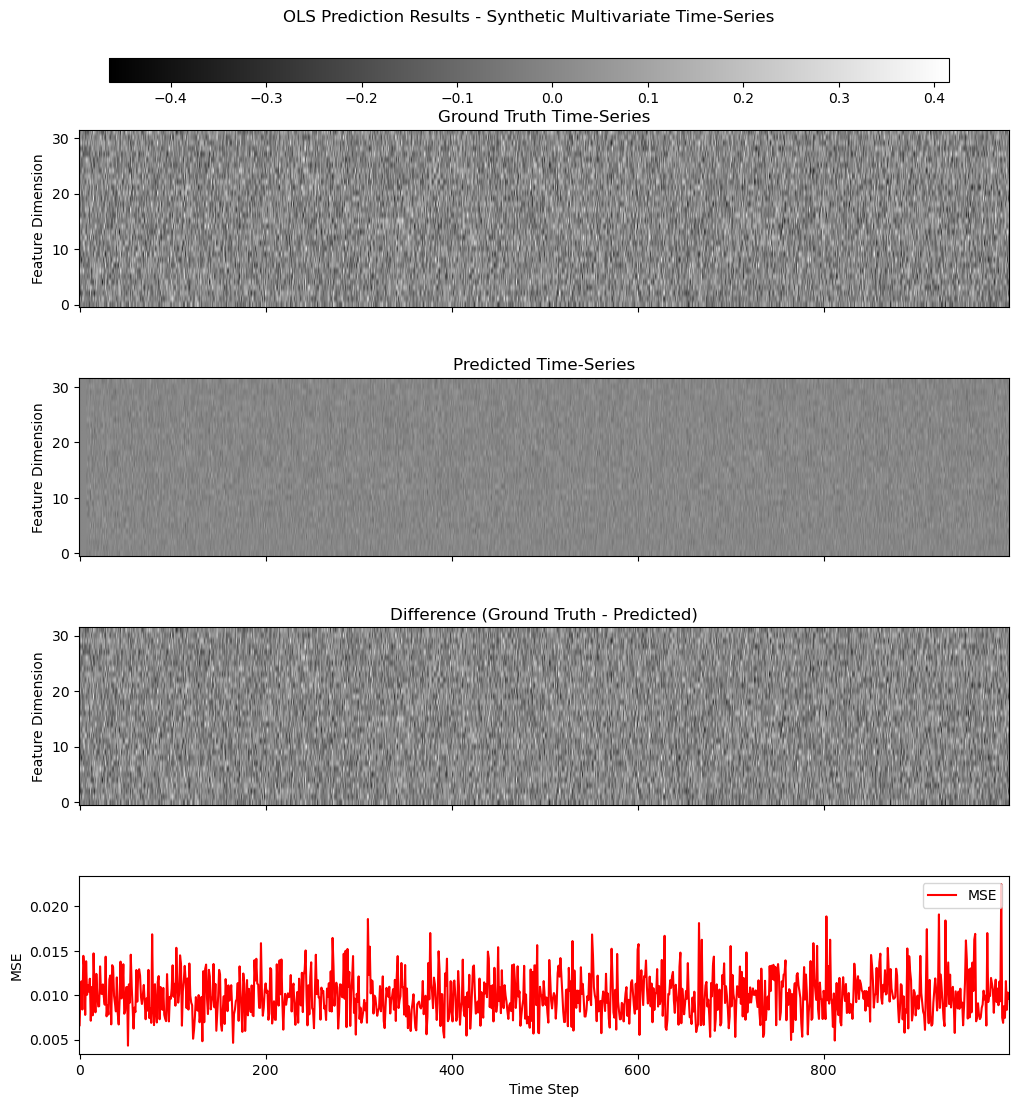

In [4]:
# Extract the first 1,000,000 datapoints and perform 80/20 split
dataset_size = 1000000
train_percent = 0.8
context_length = 8 # p = 8

# Extract data components
synthetic_data = data[0][:dataset_size] # First 1M datapoints
gt_coefficient_matrices = data[1] # Ground truth coefficients
gt_covariance_matrix = data[2] # Ground truth noise covariance

print(f"Using {dataset_size} datapoints")
print(f"Data shape: {synthetic_data.shape}")

# Perform 80/20 split
train_size = int(dataset_size * train_percent)
train_data = synthetic_data[:train_size]
test_data = synthetic_data[train_size:]

print(f"Training data: {train_data.shape}")
print(f"Test data: {test_data.shape}")

# Prepare training data for OLS
X_train, Y_train = prepare_data(train_data, context_length)
print(f"X_train shape: {X_train.shape}")
print(f"Y_train shape: {Y_train.shape}")

# Train OLS model (ordinary least squares)
print("Training OLS model...")
A_estimates = estimate_coefficients(X_train, Y_train, context_length)
print(f"OLS training complete. Estimated {len(A_estimates)} coefficient matrices.")

# Generate predictions on full dataset for visualization
print("Generating predictions...")
full_predictions = np.zeros_like(synthetic_data)

for t in range(context_length, dataset_size):
    x_t_pred = np.zeros(synthetic_data.shape[1])
    for i in range(context_length):
        prior_idx = t - (i + 1)
        if prior_idx >= 0:
            x_t_pred += A_estimates[i] @ synthetic_data[prior_idx]
    full_predictions[t] = x_t_pred

# Calculate prediction error statistics
test_start_idx = train_size
test_predictions = full_predictions[test_start_idx:]
test_actual = test_data

# Calculate MSE on test set
test_mse = MSE(test_actual, test_predictions)
print(f"Test MSE: {test_mse:.6f}")

# Calculate prediction error covariance for PECEP
test_residuals = test_actual - test_predictions
test_error_cov = np.cov(test_residuals.T, bias=True)
test_pecep = gauss_entropy(test_error_cov, synthetic_data.shape[1])
gt_entropy = gauss_entropy(gt_covariance_matrix, synthetic_data.shape[1])

print(f"Test PECEP: {test_pecep:.6f}")
print(f"Ground truth entropy: {gt_entropy:.6f}")
print(f"PECEP vs GT entropy difference: {test_pecep - gt_entropy:.6f}")

# Visualize the results using your modified function
print("Creating visualization...")
visualize_MSE(
    gt_data=synthetic_data[:1000],
    predicted_data=full_predictions[:1000],
    title="OLS Prediction Results - Synthetic Multivariate Time-Series"
)

In [5]:

def visualize_coefficient_matrices(gt_coefficients, estimated_coefficients, title="Coefficient Matrix Comparison"):
    """
    Visualize ground truth, estimated, and MSE coefficient matrices as heatmaps.

    Parameters:
    - gt_coefficients: List of ground truth coefficient matrices [A1, A2, ..., Ap]
    - estimated_coefficients: List of estimated coefficient matrices [A1_est, A2_est, ..., Ap_est]
    - title: Title for the overall figure
    """
    p = len(gt_coefficients)
    assert p == len(estimated_coefficients), "Ground truth and estimated lists must be of same length"

    # Prepare figure: 3 rows (GT, Estimated, MSE), p columns
    fig, axes = plt.subplots(3, p, figsize=(4*p + 2, 12))

    if p == 1:
        axes = axes.reshape(3, 1)

    # Determine shared color scale for GT and Estimated
    all_matrices = gt_coefficients + estimated_coefficients
    vmin = min(np.min(matrix) for matrix in all_matrices)
    vmax = max(np.max(matrix) for matrix in all_matrices)

    # Determine color scale for MSE
    mse_matrices = [np.square(gt - est) for gt, est in zip(gt_coefficients, estimated_coefficients)]
    mse_vmin = 0
    mse_vmax = max(np.max(mse) for mse in mse_matrices)

    # Plot each matrix
    for i in range(p):
        # Ground Truth
        im1 = axes[0, i].imshow(gt_coefficients[i], cmap='RdBu_r', vmin=vmin, vmax=vmax, aspect='auto')
        axes[0, i].set_title(f'Ground Truth A{i+1}', fontsize=12, fontweight='bold')
        axes[0, i].set_xlabel('Dimension')
        axes[0, i].set_ylabel('Dimension')

        # Estimated
        im2 = axes[1, i].imshow(estimated_coefficients[i], cmap='RdBu_r', vmin=vmin, vmax=vmax, aspect='auto')
        axes[1, i].set_title(f'Estimated A{i+1}', fontsize=12, fontweight='bold')
        axes[1, i].set_xlabel('Dimension')
        axes[1, i].set_ylabel('Dimension')

        # MSE
        im3 = axes[2, i].imshow(mse_matrices[i], cmap='OrRd', vmin=mse_vmin, vmax=mse_vmax, aspect='auto')
        axes[2, i].set_title(f'MSE A{i+1}', fontsize=12, fontweight='bold')
        axes[2, i].set_xlabel('Dimension')
        axes[2, i].set_ylabel('Dimension')

    # Adjust layout to make room for colorbars and title
    plt.subplots_adjust(top=0.92, right=0.86, wspace=0.4, hspace=0.4)

    # Shared colorbar for GT and Estimated
    cbar_ax1 = fig.add_axes([0.88, 0.55, 0.015, 0.35])  # Top half
    cbar1 = fig.colorbar(im1, cax=cbar_ax1)
    cbar1.set_label('Coefficient Value', rotation=270, labelpad=15)

    # Separate colorbar for MSE
    cbar_ax2 = fig.add_axes([0.88, 0.12, 0.015, 0.35])  # Bottom half
    cbar2 = fig.colorbar(im3, cax=cbar_ax2)
    cbar2.set_label('MSE', rotation=270, labelpad=15)

    # Add overall title
    fig.suptitle(title, fontsize=16, fontweight='bold', y=0.98)

    plt.show()
    plt.close()


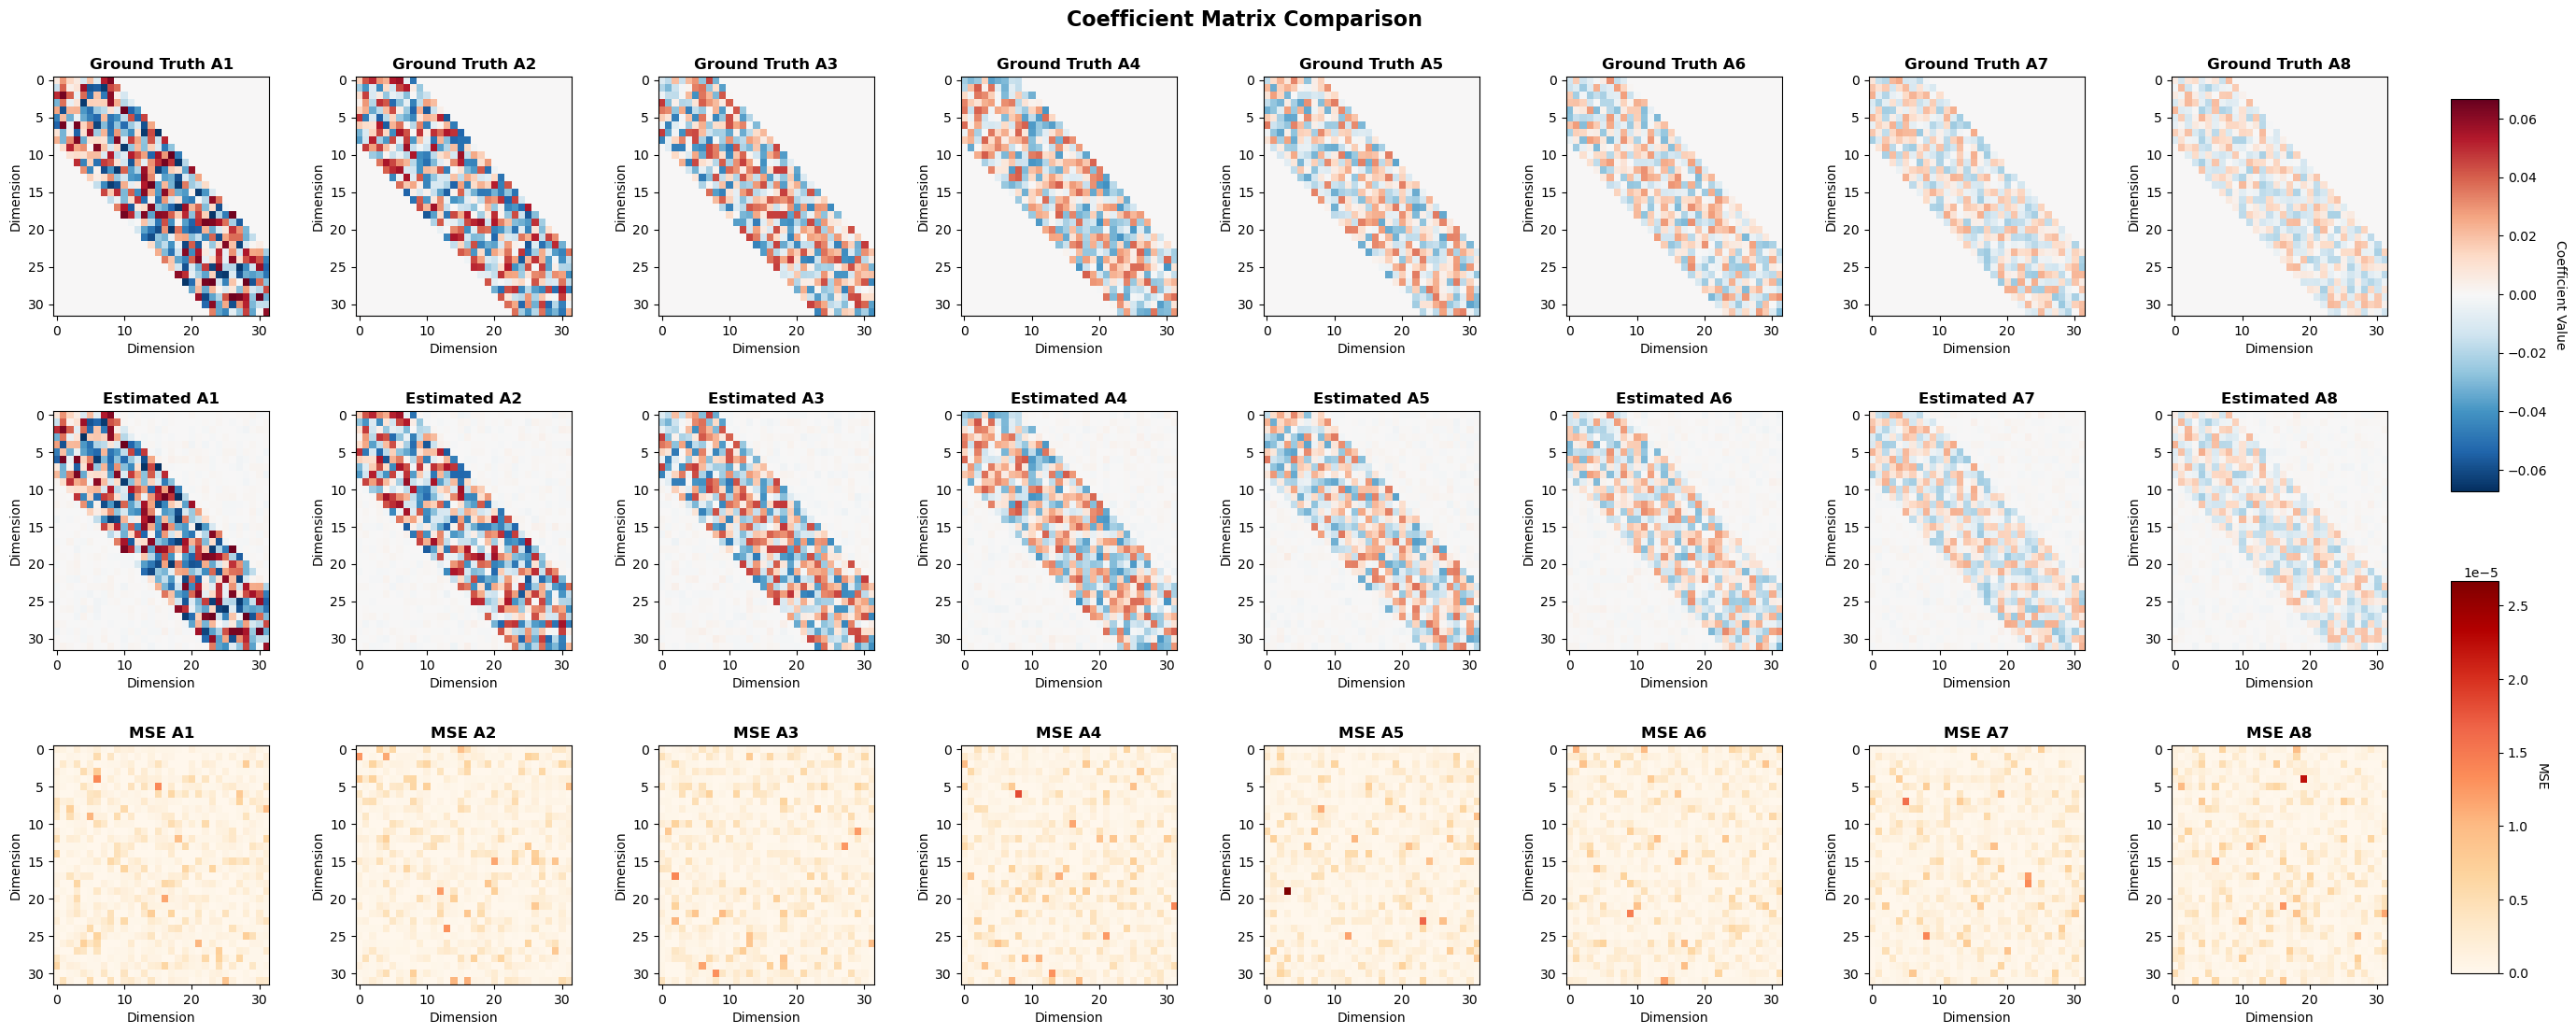

In [6]:
visualize_coefficient_matrices(data[1], A_estimates)